# BGG Score Prediction

Predicting the `bayesaverage` score of the 5000 most rated board and card games on BoardGameGeek. The pipeline: data collection via API, cleaning, EDA, feature selection, and a comparison of several regression models.

In [1]:
import os
import time
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, SelectFromModel, mutual_info_regression, RFECV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error



## 1. Load the data and filter the 5000 most rated games

The starting point is the official `boardgames_ranks.csv`. Expansions are removed, then the 5000 games with the most ratings are kept.

In [ ]:
df = pd.read_csv('boardgames_ranks.csv')
df_filtered = df[df['is_expansion'] == 0]
df_filtered = df_filtered.sort_values('usersrated', ascending=False)
df_top5000 = df_filtered.head(5000)

print(df_top5000.shape)
print(df_top5000[['id', 'name', 'usersrated', 'rank']].head(10))

In [ ]:
df_top5000.to_csv('top5000_games.csv', index=False)

## 2. Fetch game details via the BGG API

The IDs are split into blocks of 20 (the maximum the API allows per request). A 3 second pause between requests keeps the process within the rate limit.

In [ ]:
load_dotenv()
token = os.getenv('BGG_TOKEN')
headers = {'Authorization': f'Bearer {token}'}


def parse_block(xml_text):
    root = ET.fromstring(xml_text)
    games = []
    for item in root.findall('item'):
        game = {}
        game['id'] = item.get('id')
        game['name'] = item.find("name[@type='primary']").get('value')
        game['yearpublished'] = item.findtext('yearpublished')
        game['minplayers'] = item.find('minplayers').get('value')
        game['maxplayers'] = item.find('maxplayers').get('value')
        game['minplaytime'] = item.find('minplaytime').get('value')
        game['maxplaytime'] = item.find('maxplaytime').get('value')
        game['minage'] = item.find('minage').get('value')
        stats = item.find('statistics/ratings')
        game['usersrated'] = stats.find('usersrated').get('value')
        game['average'] = stats.find('average').get('value')
        game['bayesaverage'] = stats.find('bayesaverage').get('value')
        game['complexity'] = stats.find('averageweight').get('value')
        games.append(game)
    return games


ids = df_top5000['id'].astype(str).tolist()
blocks = [ids[i:i + 20] for i in range(0, len(ids), 20)]

all_games = []
for i, block in enumerate(blocks):
    url = f"https://boardgamegeek.com/xmlapi2/thing?id={','.join(block)}&type=boardgame&stats=1"
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        games = parse_block(response.text)
        all_games.extend(games)
        print(f'Block {i + 1}/{len(blocks)} ({len(all_games)} games)')
    else:
        print(f'Block {i + 1} error: {response.status_code}')

    time.sleep(3)

df_games = pd.DataFrame(all_games)
df_games.to_csv('bgg_raw_data.csv', index=False)
print('Done!')

## 3. Load the raw data and add yearpublished

The API parser returns `yearpublished` empty, because the value is stored as an XML attribute rather than as text. The column is therefore merged back in from the ranks dataset.

In [2]:
df = pd.read_csv('bgg_raw_data.csv')

# yearpublished comes back empty from the API parser (the value lives in the XML
# attribute, not the text). The column is added back from the ranks dataset.
df_top5000 = pd.read_csv('top5000_games.csv')

df = df.drop(columns=['yearpublished'])
df['id'] = df['id'].astype(int)
df_top5000['id'] = df_top5000['id'].astype(int)
df = df.merge(df_top5000[['id', 'yearpublished']], on='id', how='left')
df.head()

,id,name,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
0,13,Catan,3,4,60,120,10,142781,7.09040,6.90249,2.2816,1995
1,822,Carcassonne,2,5,30,45,7,140178,7.41660,7.29878,1.8846,2000
2,30549,Pandemic,2,4,45,45,8,135383,7.51287,7.40339,2.3939,2008
3,167791,Terraforming Mars,1,5,120,120,12,113682,8.33408,8.18309,3.2728,2016
4,266192,Wingspan,1,5,40,70,10,113544,7.99763,7.84451,2.4810,2019


## 4. Missing values and a first look at the data

In [3]:
df = df.replace('', np.nan)
print(df.isna().mean())

id               0.0
name             0.0
minplayers       0.0
maxplayers       0.0
minplaytime      0.0
maxplaytime      0.0
minage           0.0
usersrated       0.0
average          0.0
bayesaverage     0.0
complexity       0.0
yearpublished    0.0
dtype: float64


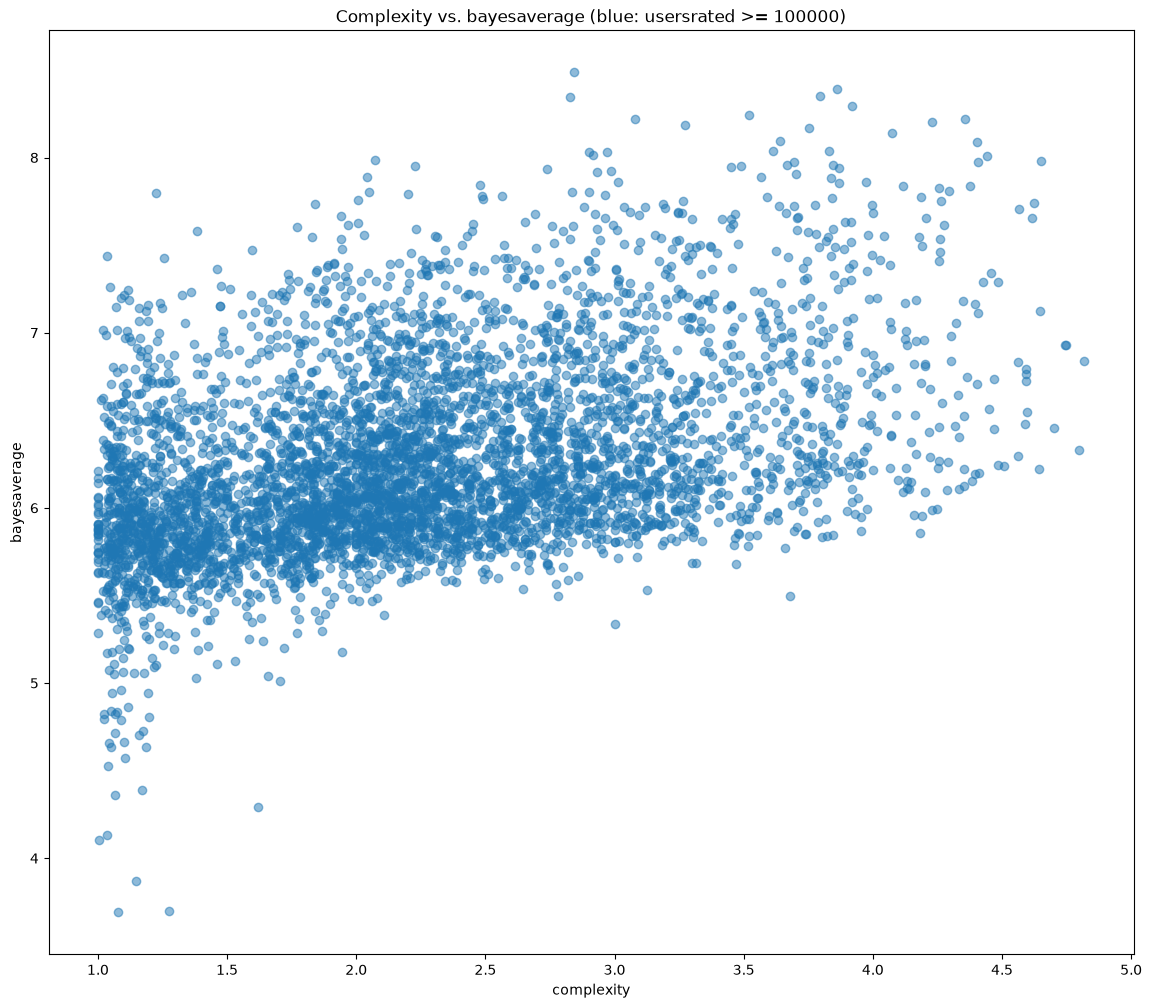

In [8]:
plt.figure(figsize=(14, 12))
plt.scatter(df['complexity'], df['bayesaverage'], alpha=0.5)
plt.xlabel('complexity')
plt.ylabel('bayesaverage')
plt.title('Complexity vs. bayesaverage (blue: usersrated >= 100000)')
plt.show();

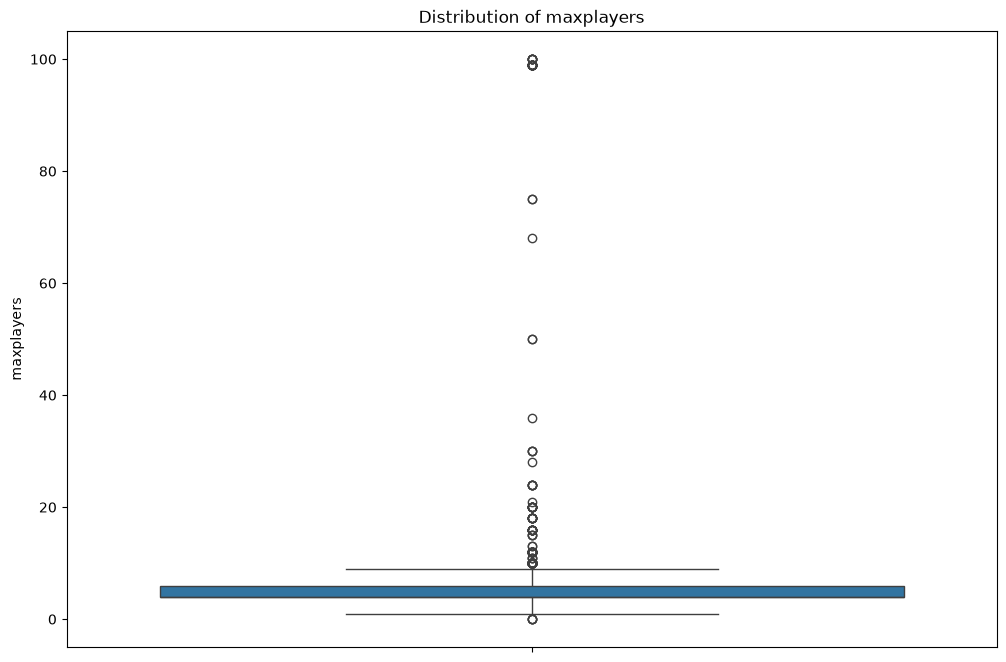

In [4]:
plt.figure(figsize=(12, 8))
sns.boxplot(y=df['maxplayers'])
plt.title('Distribution of maxplayers')
plt.ylabel('maxplayers')
plt.show()

## 5. Data types, summary statistics and outliers

Looking at `describe()` reveals several implausible values (for example 0 players, 0 play time, or release years before 1900). These are filtered out.

In [5]:
num_cols = ['minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'usersrated', 'average', 'bayesaverage', 'complexity']
df[num_cols] = df[num_cols].astype(float)

In [6]:
df.describe()

,id,minplayers,maxplayers,minplaytime,maxplaytime,minage,usersrated,average,bayesaverage,complexity,yearpublished
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,176386.826400,1.862000,5.47900,50.582200,76.36960,10.732400,5079.884400,6.983714,6.262329,2.238500,2000.93340
std,130360.405517,0.715163,8.08667,44.861031,206.40876,2.681684,9770.501732,0.693650,0.533913,0.802301,180.17408
min,1.000000,0.000000,0.00000,0.000000,0.00000,0.000000,818.000000,2.422530,3.689980,1.000000,-3500.00000
25%,37385.250000,1.000000,4.00000,30.000000,30.00000,8.000000,1225.000000,6.585978,5.899185,1.634250,2008.00000
50%,177353.000000,2.000000,4.00000,40.000000,60.00000,10.000000,2043.000000,7.012610,6.153360,2.153800,2015.00000
75%,279909.750000,2.000000,6.00000,60.000000,90.00000,13.000000,4427.000000,7.433295,6.544437,2.768825,2020.00000
max,465819.000000,8.000000,100.00000,720.000000,12000.00000,21.000000,142781.000000,9.141980,8.485540,4.818600,2027.00000


In [7]:
print('minplayers == 0:', (df['minplayers'] == 0).sum())
print('minplayers > 6:', (df['minplayers'] > 6).sum())
print('maxplayers == 0:', (df['maxplayers'] == 0).sum())
print('maxplayers > 20:', (df['maxplayers'] > 20).sum())
print('minplaytime == 0:', (df['minplaytime'] == 0).sum())
print('maxplaytime > 600:', (df['maxplaytime'] > 600).sum())
print('yearpublished < 1900:', (df['yearpublished'] < 1900).sum())
print('yearpublished > 2026:', (df['yearpublished'] > 2026).sum())

minplayers == 0: 2
minplayers > 6: 4
maxplayers == 0: 4
maxplayers > 20: 48
minplaytime == 0: 7
maxplaytime > 600: 15
yearpublished < 1900: 47
yearpublished > 2026: 1


In [8]:
df = df.loc[
    (df['yearpublished'] >= 1900) &
    (df['yearpublished'] <= 2026) &
    (df['minplayers'] != 0) &
    (df['maxplayers'] != 0) &
    (df['minplaytime'] != 0) &
    (df['maxplaytime'] <= 600)
]
print(len(df))

4931


In [9]:
df.to_csv('bgg_clean_data.csv', index=False)

## 6. Exploratory data analysis

`average` and `usersrated` are removed before modeling, since they feed directly into `bayesaverage` (data leakage).

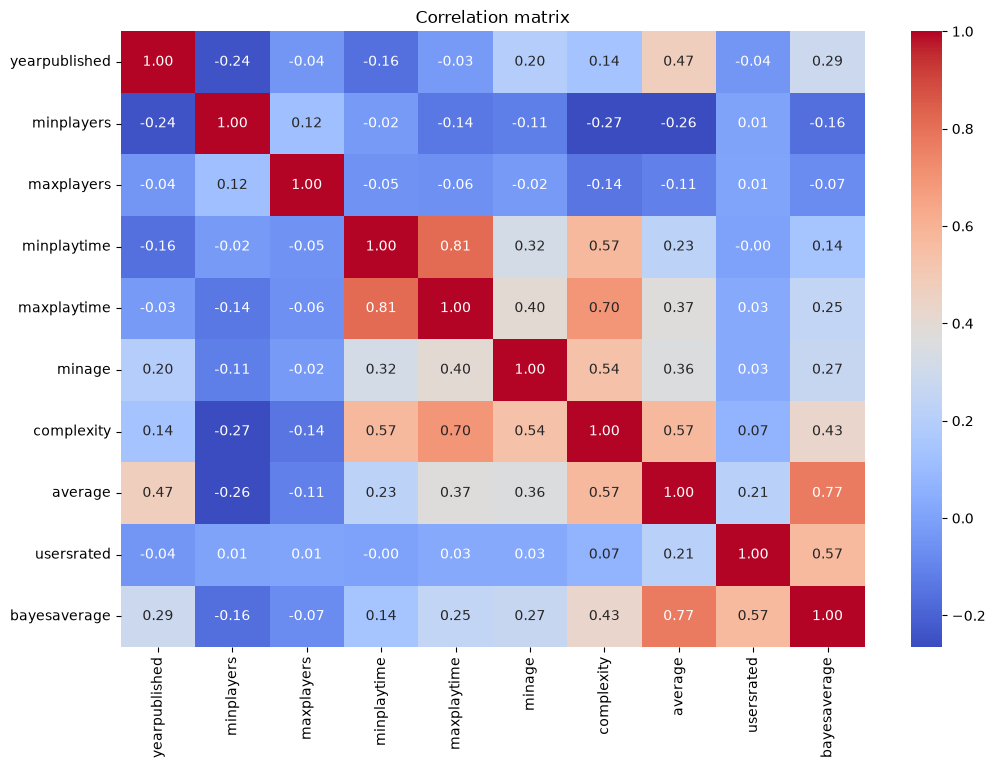

In [10]:
df = pd.read_csv('bgg_clean_data.csv')
df = df[['yearpublished', 'minplayers', 'maxplayers', 'minplaytime', 'maxplaytime', 'minage', 'complexity', 'average', 'usersrated', 'bayesaverage']]

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.show();

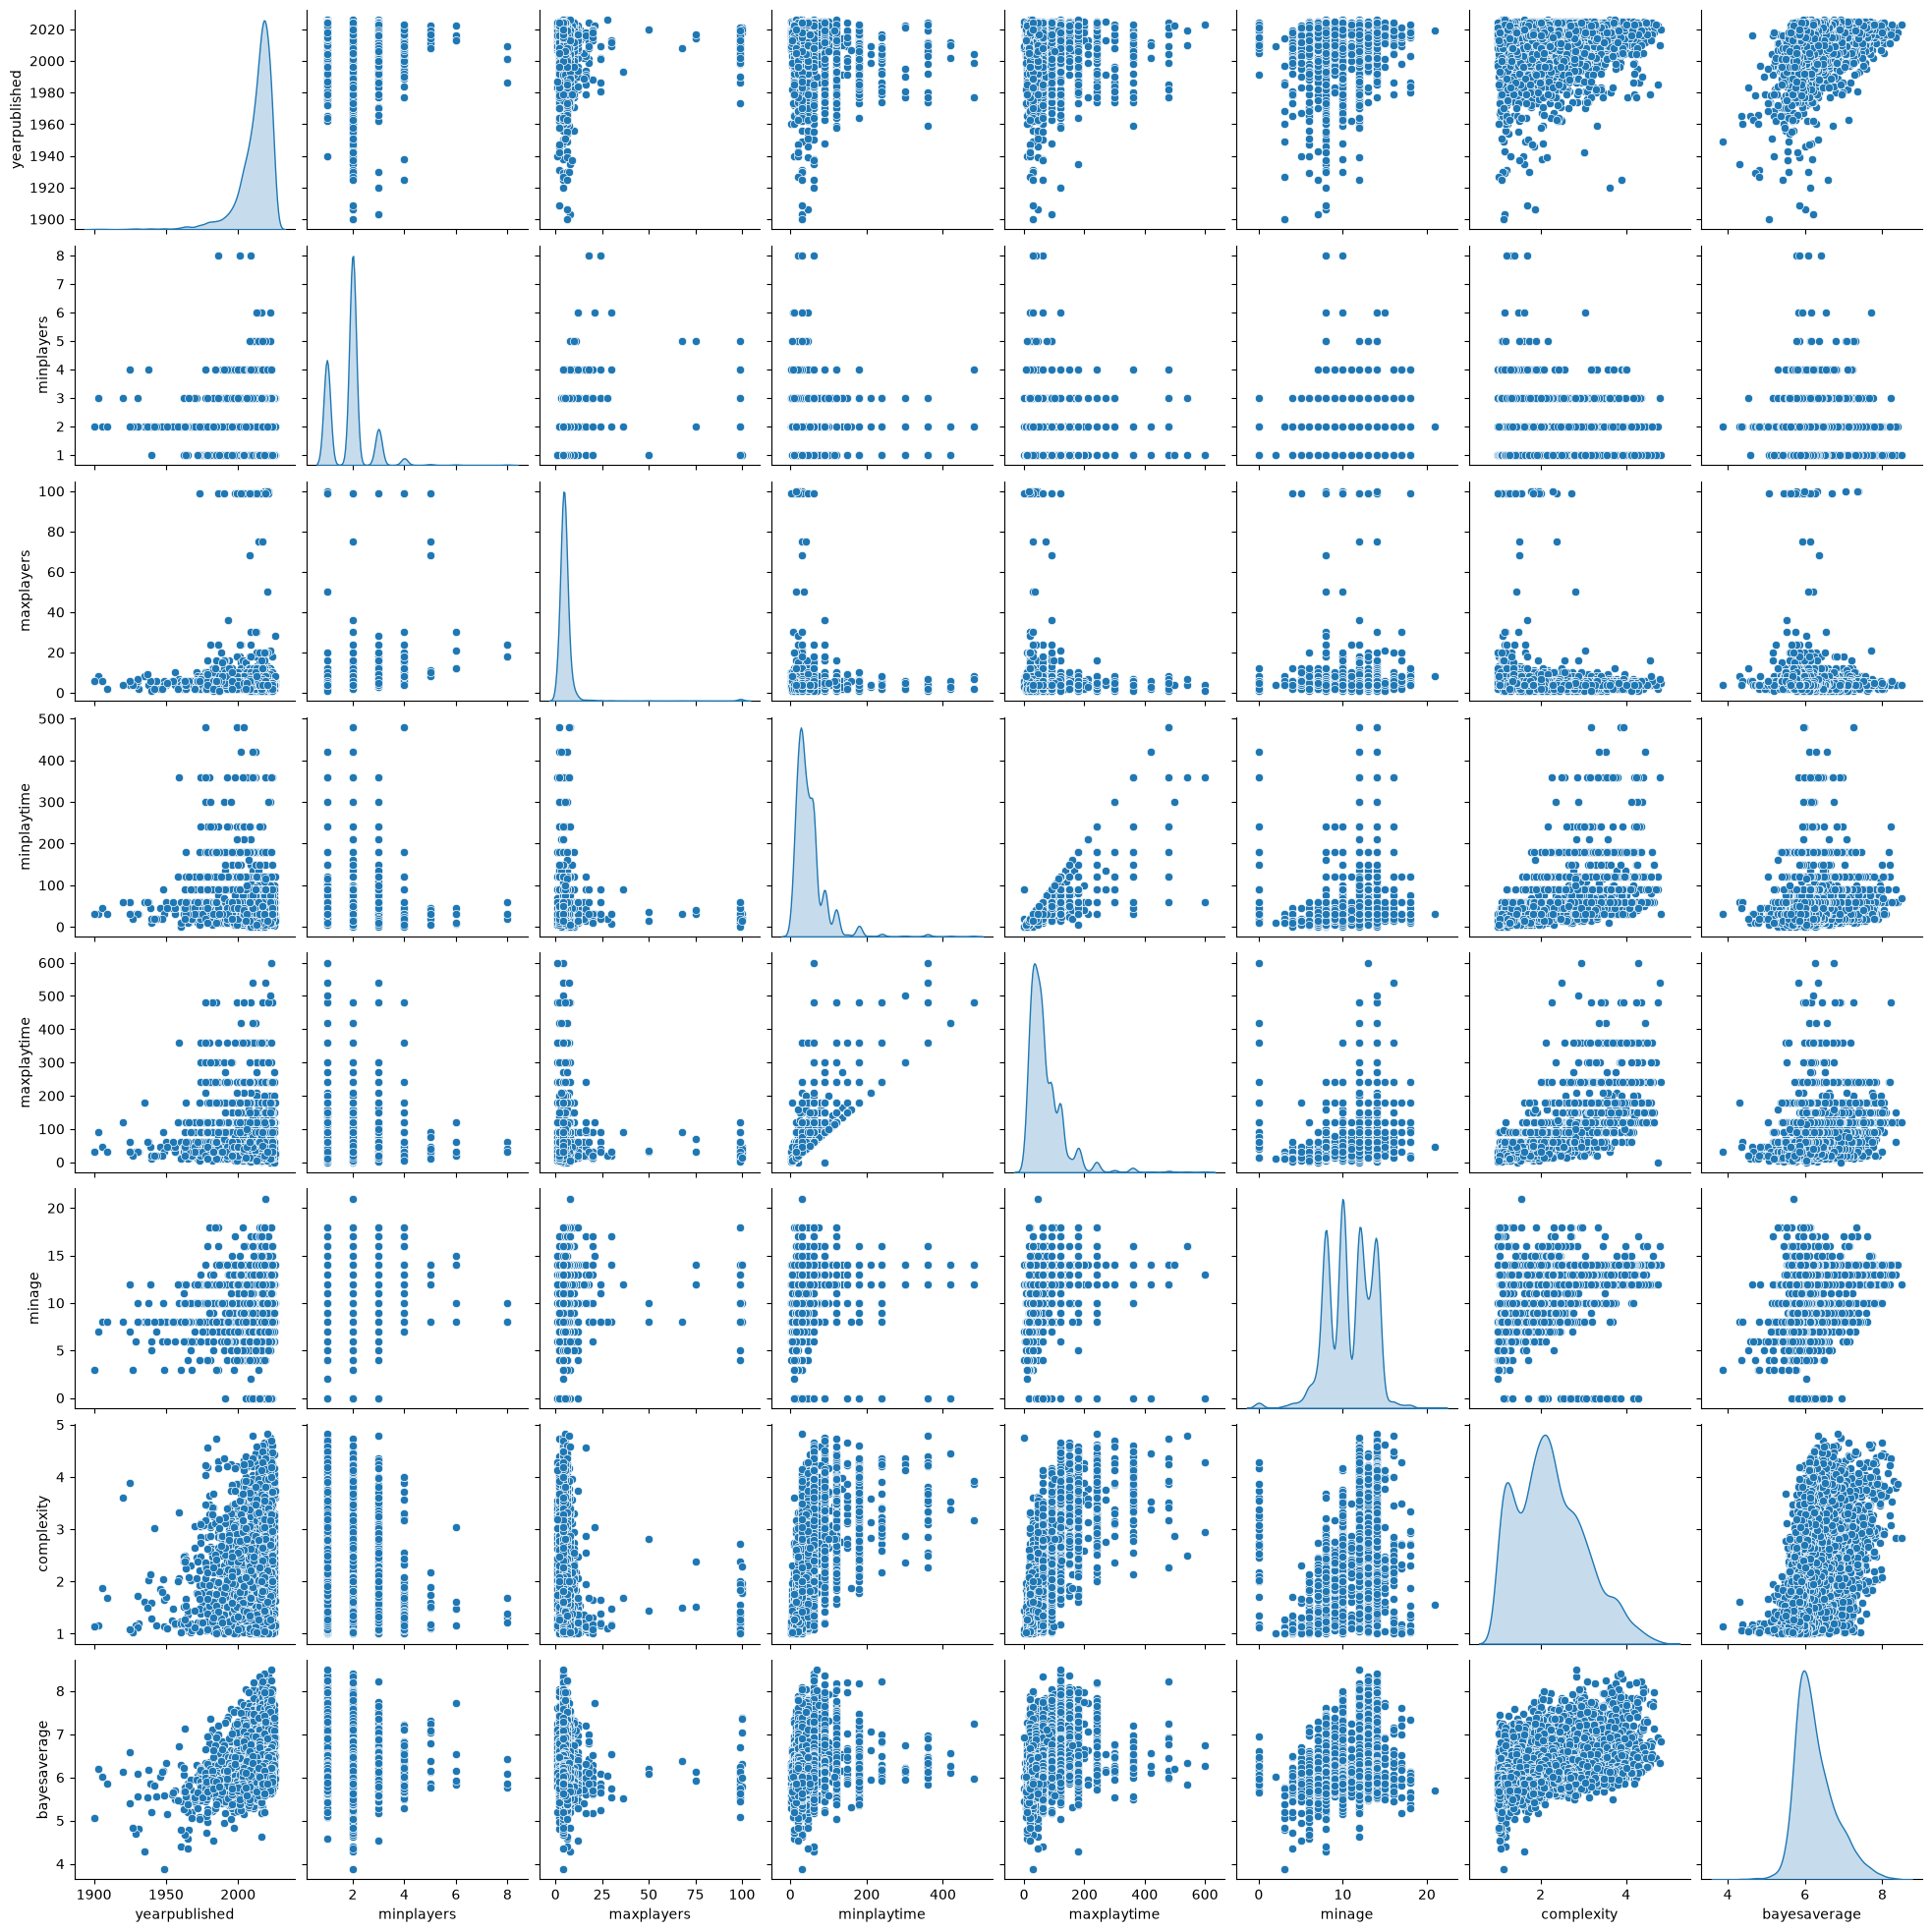

In [11]:
df = df.drop(columns=['average', 'usersrated'])
sns.pairplot(df, diag_kind='kde')
plt.show();

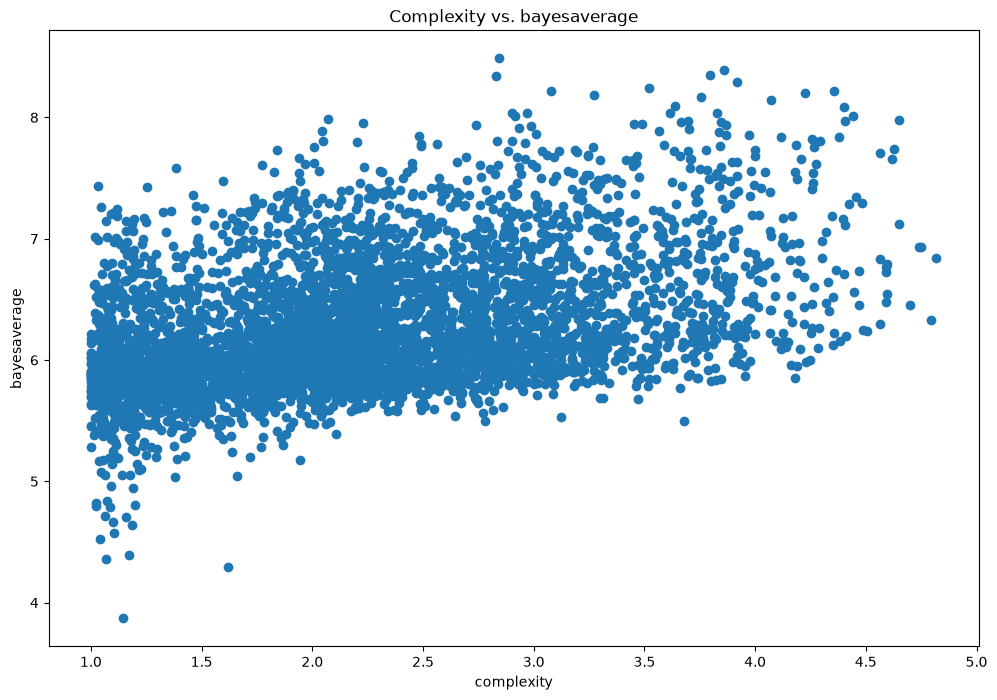

In [12]:
plt.figure(figsize=(12, 8))
plt.scatter('complexity', 'bayesaverage', data=df)
plt.xlabel('complexity')
plt.ylabel('bayesaverage')
plt.title('Complexity vs. bayesaverage')
plt.show()

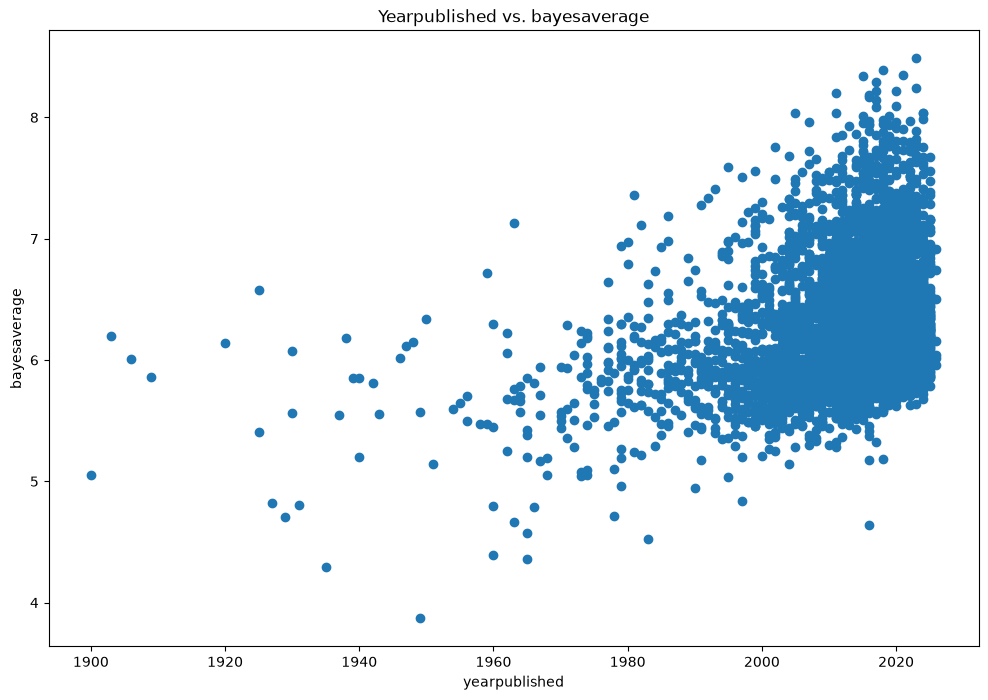

In [13]:
plt.figure(figsize=(12, 8))
plt.scatter('yearpublished', 'bayesaverage', data=df)
plt.xlabel('yearpublished')
plt.ylabel('bayesaverage')
plt.title('Yearpublished vs. bayesaverage')
plt.show()

## 7. Feature Selection

Five approaches from the three categories filtering, embedded and wrapper, used to identify the most informative features.

In [14]:
X = df.drop(columns='bayesaverage')
y = df['bayesaverage']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=161)

In [16]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

### Filtering: SelectKBest

In [17]:
sel = SelectKBest(score_func=mutual_info_regression, k=4)
sel.fit(X_train, y_train)
KB_mask = sel.get_support()
KB_selected_features = X.columns[KB_mask]
print(KB_selected_features)

Index(['yearpublished', 'maxplaytime', 'minage', 'complexity'], dtype='str')


### Embedded: Lasso and Random Forest

In [18]:
lasso = Lasso(alpha=0.01)
select = SelectFromModel(estimator=lasso, threshold=1e-10)
select.fit(X_train, y_train)
lasso_mask = select.get_support()
lasso_selected_features = X.columns[lasso_mask]
print(lasso_selected_features)

Index(['yearpublished', 'maxplayers', 'minplaytime', 'complexity'], dtype='str')


In [19]:
rf = RandomForestRegressor()
select = SelectFromModel(estimator=rf, threshold=1e-10)
select.fit(X_train, y_train)
rf_mask = select.get_support()
rf_selected_features = X.columns[rf_mask]
print(rf_selected_features)

Index(['yearpublished', 'minplayers', 'maxplayers', 'minplaytime',
       'maxplaytime', 'minage', 'complexity'],
      dtype='str')


In [20]:
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

complexity       0.458207
yearpublished    0.193246
maxplaytime      0.087168
minplaytime      0.080234
minage           0.074930
maxplayers       0.069101
minplayers       0.037114
dtype: float64


### Wrapper: RFECV

In [21]:
crossval = KFold(n_splits=5, random_state=161, shuffle=True)
lm = LinearRegression()
rfecv_lm = RFECV(estimator=lm, cv=crossval, step=1)
rfecv_lm.fit(X_train, y_train)
lr_mask = rfecv_lm.get_support()

In [22]:
lm_wr_selected_features = X.columns[rfecv_lm.support_]
print(lm_wr_selected_features)

Index(['yearpublished', 'minplaytime', 'complexity'], dtype='str')


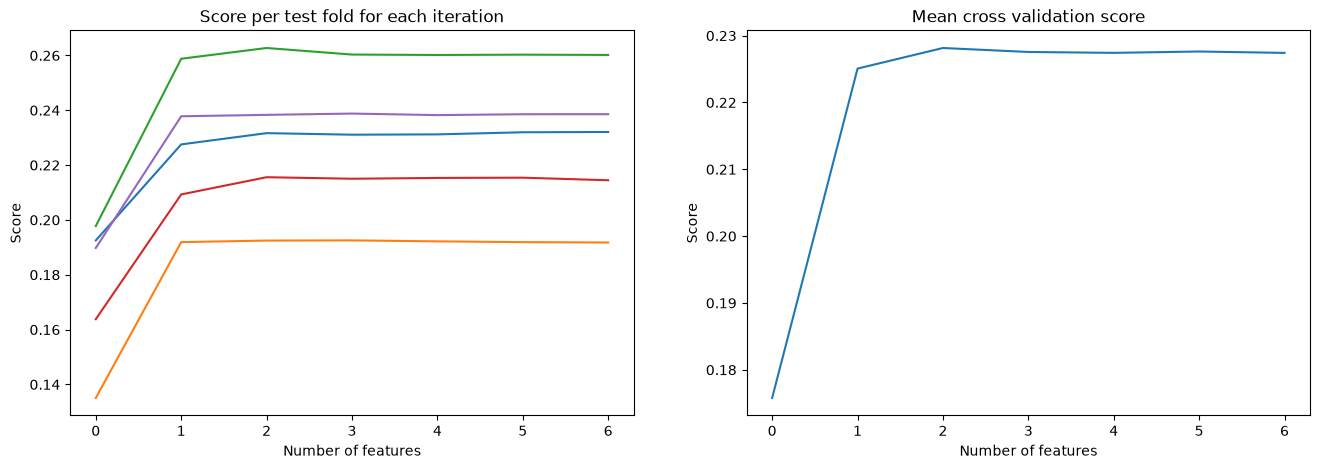

Number of features selected : 3


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i in range(5):
    ax1.plot(rfecv_lm.cv_results_[f'split{i}_test_score'])
ax1.set_xlabel('Number of features')
ax1.set_ylabel('Score')
ax1.set_title('Score per test fold for each iteration')

ax2.plot(rfecv_lm.cv_results_['mean_test_score'])
ax2.set_xlabel('Number of features')
ax2.set_ylabel('Score')
ax2.set_title('Mean cross validation score')

plt.show();

print('Number of features selected :', rfecv_lm.n_features_)

In [24]:
crossval = KFold(n_splits=5, random_state=161, shuffle=True)
rf = RandomForestRegressor()
rfecv = RFECV(estimator=rf, cv=crossval, step=1)
rfecv.fit(X_train, y_train)
rf_wr_mask = rfecv.get_support()

In [25]:
rf_wr_selected_features = X.columns[rfecv.support_]
print(rf_wr_selected_features)

Index(['yearpublished', 'minplayers', 'maxplayers', 'minplaytime',
       'maxplaytime', 'minage', 'complexity'],
      dtype='str')


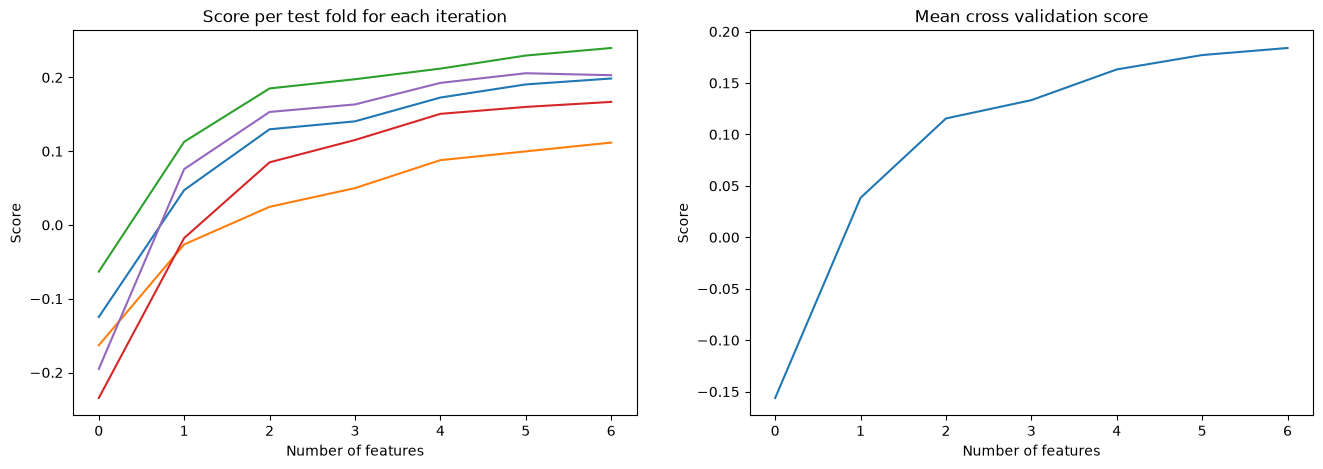

Number of features selected : 7


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i in range(5):
    ax1.plot(rfecv.cv_results_[f'split{i}_test_score'])
ax1.set_xlabel('Number of features')
ax1.set_ylabel('Score')
ax1.set_title('Score per test fold for each iteration')

ax2.plot(rfecv.cv_results_['mean_test_score'])
ax2.set_xlabel('Number of features')
ax2.set_ylabel('Score')
ax2.set_title('Mean cross validation score')

plt.show();

print('Number of features selected :', rfecv.n_features_)

### Comparison of the methods

In [27]:
data = {
    'SelectKBest': KB_mask,
    'Lasso_embedded': lasso_mask,
    'RandomForest_embedded': rf_mask,
    'LinearRegression_wrapper': lr_mask,
    'RandomForest_wrapper': rf_wr_mask
}

df_features = pd.DataFrame(data, index=X.columns)

In [28]:
df_features.head(7)

,SelectKBest,Lasso_embedded,RandomForest_embedded,LinearRegression_wrapper,RandomForest_wrapper
yearpublished,True,True,True,True,True
minplayers,False,False,True,False,True
maxplayers,False,True,True,False,True
minplaytime,False,True,True,True,True
maxplaytime,True,False,True,False,True
minage,True,False,True,False,True
complexity,True,True,True,True,True


## 8. Model training and comparison

Based on the feature selection, `complexity`, `yearpublished` and `minplaytime` are used. Linear Regression, Lasso and Random Forest are compared.

In [29]:
X_train_selected = X_train[['minplaytime', 'yearpublished', 'complexity']]
X_test_selected = X_test[['minplaytime', 'yearpublished', 'complexity']]

In [30]:
lm = LinearRegression()
lm.fit(X_train_selected, y_train)
y_predicted = lm.predict(X_test_selected)
lm_results = {'R_squared': r2_score(y_true=y_test, y_pred=y_predicted),
              'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
              'RMSE': root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
              'model': 'LinearRegression'}
print(f'The R squared score is: {r2_score(y_true=y_test, y_pred=y_predicted)}')
print(f'The mean absolute error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean squared error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R squared score is: 0.27182578066623486
The mean absolute error is: 0.37463254576097477
The root mean squared error is: 0.47614162993882764


In [31]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_selected, y_train)
y_predicted = lasso.predict(X_test_selected)
lasso_results = {'R_squared': r2_score(y_true=y_test, y_pred=y_predicted),
                 'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                 'RMSE': root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                 'model': 'Lasso'}
print(f'The R squared score is: {r2_score(y_true=y_test, y_pred=y_predicted)}')
print(f'The mean absolute error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean squared error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R squared score is: 0.2653627808734381
The mean absolute error is: 0.3755219891176905
The root mean squared error is: 0.47824998880659025


In [32]:
rf = RandomForestRegressor(random_state=161)
rf.fit(X_train_selected, y_train)
y_predicted = rf.predict(X_test_selected)
rf_results = {'R_squared': r2_score(y_true=y_test, y_pred=y_predicted),
              'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
              'RMSE': root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
              'model': 'RF'}
print(f'The R squared score is: {r2_score(y_true=y_test, y_pred=y_predicted)}')
print(f'The mean absolute error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean squared error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R squared score is: 0.13447626800653834
The mean absolute error is: 0.4092855047190461
The root mean squared error is: 0.5191083265457472


### Hyperparameter tuning (GridSearchCV)

In [33]:
parameters = {'n_estimators': range(50, 250, 25),
              'max_depth': [2, 3, 4, 5, 6, 7]}
crossval = KFold(n_splits=5, random_state=161, shuffle=True)
grid_search = GridSearchCV(rf, parameters, cv=crossval)
grid_search.fit(X_train_selected, y_train)
print(grid_search.best_params_)

{'max_depth': 5, 'n_estimators': 50}


In [34]:
y_predicted = grid_search.best_estimator_.predict(X_test_selected)
rf_optimized_results = {'R_squared': r2_score(y_true=y_test, y_pred=y_predicted),
                        'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                        'RMSE': root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                        'model': 'RF_optimized'}
print(f'The R squared score is: {r2_score(y_true=y_test, y_pred=y_predicted)}')
print(f'The mean absolute error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean squared error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R squared score is: 0.2735711452086551
The mean absolute error is: 0.3738841473839362
The root mean squared error is: 0.47557065442559476


In [35]:
parameters = {'alpha': np.arange(0.001, 0.021, 0.001)}
grid_search = GridSearchCV(lasso, parameters, cv=crossval)
grid_search.fit(X_train_selected, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(0.001)}


In [36]:
y_predicted = grid_search.best_estimator_.predict(X_test_selected)
lasso_optimized_results = {'R_squared': r2_score(y_true=y_test, y_pred=y_predicted),
                           'MAE': mean_absolute_error(y_true=y_test, y_pred=y_predicted),
                           'RMSE': root_mean_squared_error(y_true=y_test, y_pred=y_predicted),
                           'model': 'Lasso_optimized'}
print(f'The R squared score is: {r2_score(y_true=y_test, y_pred=y_predicted)}')
print(f'The mean absolute error is: {mean_absolute_error(y_true=y_test, y_pred=y_predicted)}')
print(f'The root mean squared error is: {root_mean_squared_error(y_true=y_test, y_pred=y_predicted)}')

The R squared score is: 0.2713333159668285
The mean absolute error is: 0.3746909954873651
The root mean squared error is: 0.47630261017308767


## 9. Residual analysis

In [37]:
residuals = y_test - y_predicted

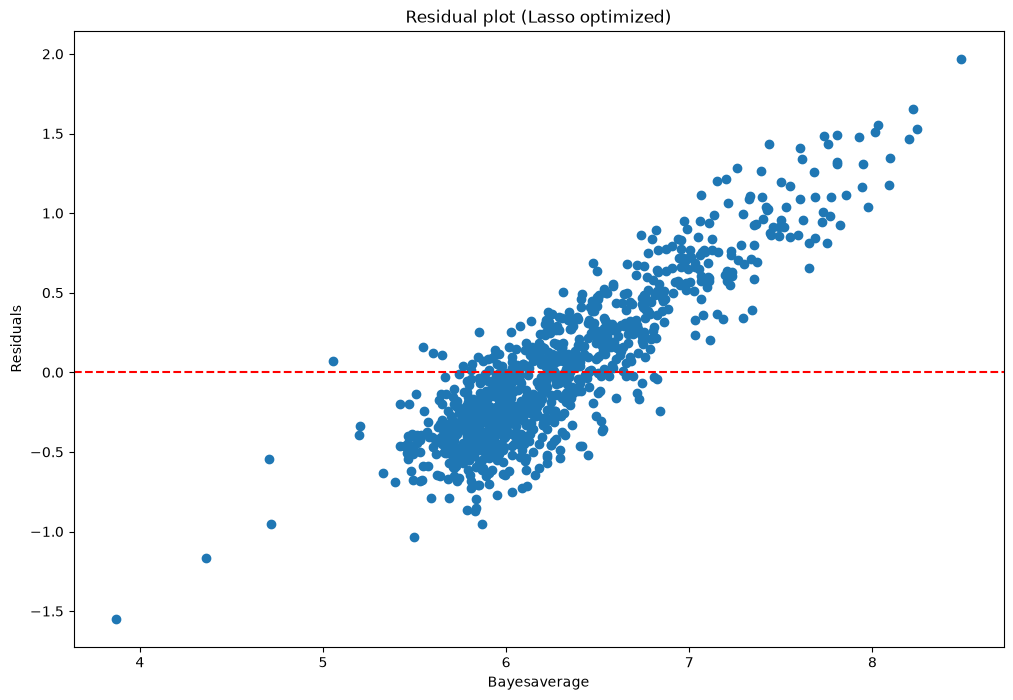

In [38]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Bayesaverage')
plt.ylabel('Residuals')
plt.title('Residual plot (Lasso optimized)')
plt.show();

## 10. Results comparison

In [39]:
df_results = pd.DataFrame([lm_results, lasso_results, rf_results, lasso_optimized_results, rf_optimized_results])
df_results = df_results.sort_values('R_squared', ascending=False)
df_results.head()

,R_squared,MAE,RMSE,model
4,0.273571,0.373884,0.475571,RF_optimized
0,0.271826,0.374633,0.476142,LinearRegression
3,0.271333,0.374691,0.476303,Lasso_optimized
1,0.265363,0.375522,0.478250,Lasso
2,0.134476,0.409286,0.519108,RF


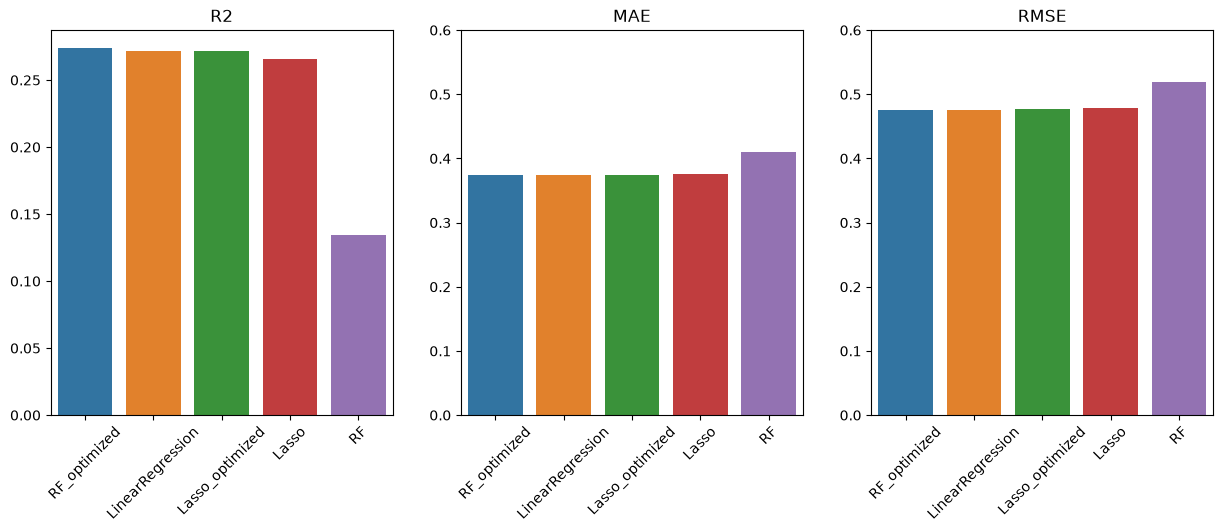

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.barplot(data=df_results, x='model', y='R_squared', hue='model', ax=axes[0])
sns.barplot(data=df_results, x='model', y='MAE', hue='model', ax=axes[1])
sns.barplot(data=df_results, x='model', y='RMSE', hue='model', ax=axes[2])
axes[1].sharey(axes[2])
axes[0].set_title('R2')
axes[1].set_title('MAE')
axes[2].set_title('RMSE')
plt.ylim(0, 0.6)
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.show();